# Aegis: ED Overload Early Warning System
### Heist Datathon 2026 | Omni Track

---

## The Problem

Emergency departments across California operate under chronic and unpredictable pressure. The standard operational model is **reactive**: staff and administrators respond only after wait times spike, beds fill, and diversion protocols are triggered. By that point, the overcrowding event is already underway and mitigating it requires emergency reallocation of staff, temporary closures, or ambulance diversion — all of which degrade patient outcomes and increase cost.

## Our Solution

Aegis is a **one-period early warning system** for ED overload. Using historical California ED encounter data, we train a logistic regression classifier that predicts — one year in advance — whether a given facility will enter a high-burden state. Predictions are surfaced in an interactive Streamlit dashboard that allows administrators to monitor risk scores, explore contributing factors, and run what-if scenarios on volume changes. The goal is to shift the operational posture from reactive to predictive.

## Dataset Overview

The dataset is the **California ED Encounters by Facility** from the California Health and Human Services Agency (HCAI), available at [data.chhs.ca.gov](https://data.chhs.ca.gov). It covers **440 facilities** across California from **2012 to 2024**, recording annual ED visit counts, admission counts, and service level designations for each facility. After cleaning and pivoting from long to wide format, the working dataset contains 4,105 rows across 9 columns. We engineered a `burden_score` proxy (ED visits normalised by the 90th-percentile statewide volume) to measure relative load across facilities.

## Section 2 — Data Loading & Exploration

We start by loading the cleaned dataset and examining its structure, distributions, and key patterns.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import warnings
warnings.filterwarnings("ignore")

PRIMARY   = "#14352a"
SECONDARY = "#f59e0b"
MUTED     = "#9ca3af"
BG        = "#f7f5f1"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#e2ded8",
    "axes.grid":        True,
    "grid.color":       "#f0ede8",
    "grid.linewidth":   0.8,
    "font.family":      "sans-serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

df = pd.read_csv("data/ca_ed_merged.csv")
print(f"Shape: {df.shape}")
print(f"Dtypes: {df.dtypes}")
print(f"Null counts: {df.isnull().sum()}")

Shape: (12311, 15)
Dtypes: year                               int64
oshpd_id                           int64
facility_name                        str
county_name                          str
er_service_level_desc                str
ed_admit                         float64
ed_visit                         float64
burden_score                     float64
facility_id                          str
treatment_stations               float64
visits_per_station               float64
true_burden_score                float64
has_treatment_data                 int64
burden_score_normalized          float64
visits_per_station_normalized    float64
dtype: object
Null counts: year                                0
oshpd_id                            0
facility_name                       0
county_name                         0
er_service_level_desc               0
ed_admit                           28
ed_visit                            7
burden_score                        7
facility_id                

The first 10 rows of the cleaned dataset, showing the pivoted wide format with one row per facility per year.

In [4]:
df.head(10)

,year,oshpd_id,facility_name,county_name,er_service_level_desc,ed_admit,ed_visit,burden_score,facility_id,treatment_stations,visits_per_station,true_burden_score,has_treatment_data,burden_score_normalized,visits_per_station_normalized
0,2012,106010735,ALAMEDA HOSPITAL,ALAMEDA,BASIC,2595.0,13727.0,0.190339,alameda-hospital,NaN,NaN,0.190339,0,NaN,NaN
1,2012,106010739,ALTA BATES SUMMIT MEDICAL CENTER-ALTA BATES CA...,ALAMEDA,BASIC,6047.0,35342.0,0.490053,alta-bates-summit-medical-center-alta-bates-ca...,NaN,NaN,0.490053,0,NaN,NaN
2,2012,106010776,CHILDRENS HOSPITAL AND RESEARCH CENTER AT OAKLAND,ALAMEDA,BASIC,6911.0,39218.0,0.543798,childrens-hospital-and-research-center-at-oakland,NaN,NaN,0.543798,0,NaN,NaN
3,2012,106010805,EDEN MEDICAL CENTER,ALAMEDA,BASIC,6324.0,31731.0,0.439983,eden-medical-center,NaN,NaN,0.439983,0,NaN,NaN
4,2012,106010846,HIGHLAND HOSPITAL,ALAMEDA,BASIC,8992.0,74202.0,1.028887,highland-hospital,NaN,NaN,1.028887,0,NaN,NaN
5,2012,106010856,KAISER FOUNDATION HOSPITAL - OAKLAND CAMPUS,ALAMEDA,BASIC,8360.0,92021.0,1.275966,kaiser-foundation-hospital---oakland-campus,NaN,NaN,1.275966,0,NaN,NaN
6,2012,106010858,KAISER FOUNDATION HOSPITAL - HAYWARD/FREMONT,ALAMEDA,BASIC,8173.0,68854.0,0.954732,kaiser-foundation-hospital---haywardfremont,NaN,NaN,0.954732,0,NaN,NaN
7,2012,106010937,ALTA BATES SUMMIT MEDICAL CENTER,ALAMEDA,BASIC,7842.0,32673.0,0.453045,alta-bates-summit-medical-center,NaN,NaN,0.453045,0,NaN,NaN
8,2012,106010967,ST. ROSE HOSPITAL,ALAMEDA,BASIC,4710.0,30479.0,0.422623,st-rose-hospital,NaN,NaN,0.422623,0,NaN,NaN
9,2012,106010987,WASHINGTON HOSPITAL - FREMONT,ALAMEDA,BASIC,7577.0,41713.0,0.578394,washington-hospital---fremont,NaN,NaN,0.578394,0,NaN,NaN


In [ ]:
#clean duplicated data
df_clean = df.drop_duplicates(subset=['facility_id', 'year']).reset_index(drop=True)

In [9]:
#Check for null value
df.isnull().values.any()

np.True_

In [10]:
df.isnull().sum()

year                                0
oshpd_id                            0
facility_name                       0
county_name                         0
er_service_level_desc               0
ed_admit                           28
ed_visit                            7
burden_score                        7
facility_id                         0
treatment_stations               3591
visits_per_station               3591
true_burden_score                   7
has_treatment_data                  0
burden_score_normalized          3591
visits_per_station_normalized    3591
dtype: int64

The Volume and Capacity XLSX provided real treatment station counts for 2021–2023. We merged this with the Encounters CSV (2012–2024) to compute a true burden ratio where available.

- `burden_score_normalized`: true ED visits / treatment stations, normalized to facility 90th percentile, clipped [0, 2.0]
- `has_treatment_data = 1`: 8,720 rows use real station counts
- `has_treatment_data = 0`: 3,591 rows fall back to the original proxy burden score

In [ ]:
new_cols = ['treatment_stations', 'true_burden_score', 'burden_score_normalized',
            'visits_per_station', 'has_treatment_data']
available = [c for c in new_cols if c in df.columns]
print("New columns from XLSX merge:")
print(df[available].describe().round(4).to_string())

In [ ]:
print("Rows with real treatment station data vs fallback:")
print(df['has_treatment_data'].value_counts().rename({1: 'Real station data', 0: 'Fallback burden_score'}).to_string())
print(f"\nReal data coverage: {df['has_treatment_data'].mean():.1%}")

The `er_service_level_desc` column captures the designation of each ED. The vast majority are BASIC facilities; only 114 rows belong to COMPREHENSIVE facilities — the highest tier.

In [3]:
print("Service level distribution:")
print(df["er_service_level_desc"].value_counts().to_string())

Service level distribution:
er_service_level_desc
BASIC            3578
STANDBY           413
COMPREHENSIVE     114


The distribution of `burden_score` across all facility-years. Values are clipped to [0, 2.0] during engineering. A score of 1.0 corresponds to the 90th-percentile statewide volume.

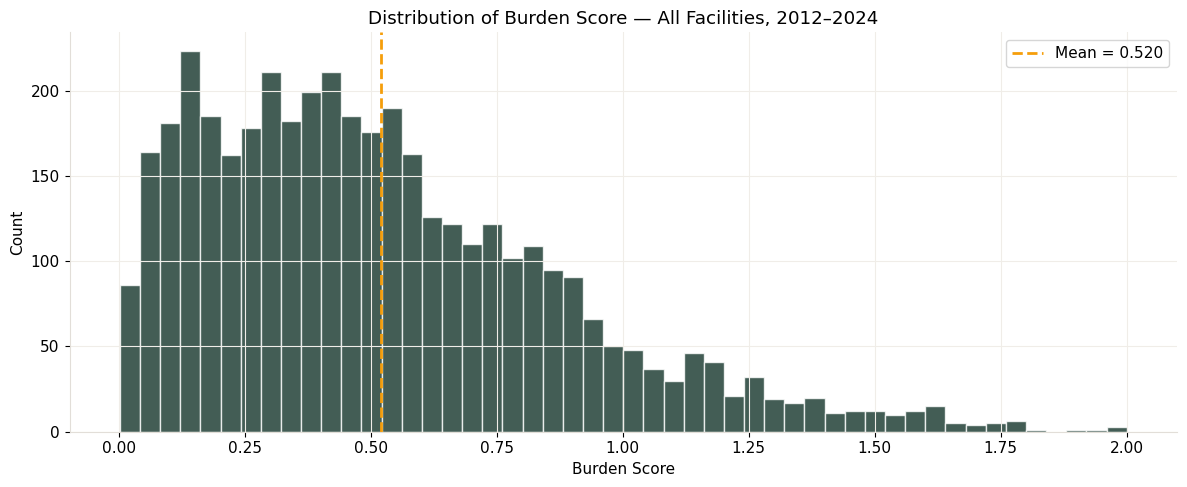

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df["burden_score"].dropna(), bins=50, color=PRIMARY, alpha=0.8, edgecolor="white")
ax.axvline(df["burden_score"].mean(), color=SECONDARY, linewidth=2, linestyle="--",
           label=f"Mean = {df['burden_score'].mean():.3f}")
ax.set_xlabel("Burden Score")
ax.set_ylabel("Count")
ax.set_title("Distribution of Burden Score — All Facilities, 2012–2024")
ax.legend()
plt.tight_layout()
plt.show()

Top 20 facilities ranked by their average `burden_score` across all available years. Kaiser Fontana leads at 1.81 — nearly double the statewide mean — followed by LAC+USC and other large urban trauma centers.

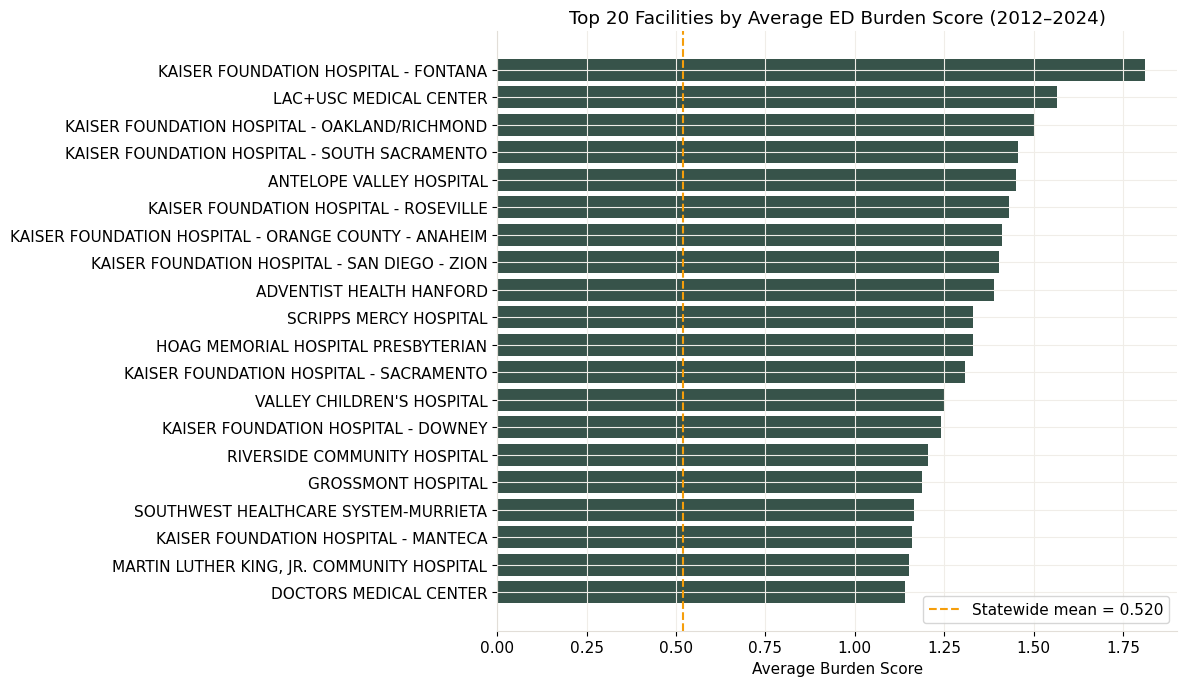

In [5]:
top20 = (
    df.groupby("facility_name")["burden_score"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20.index, top20.values, color=PRIMARY, alpha=0.85)
ax.axvline(df["burden_score"].mean(), color=SECONDARY, linewidth=1.5, linestyle="--",
           label=f"Statewide mean = {df['burden_score'].mean():.3f}")
ax.set_xlabel("Average Burden Score")
ax.set_title("Top 20 Facilities by Average ED Burden Score (2012–2024)")
ax.legend()
plt.tight_layout()
plt.show()

Statewide average burden score by year. The 2020 dip reflects COVID-19 pandemic effects on ED utilization; burden has climbed back toward and past pre-pandemic levels by 2024.

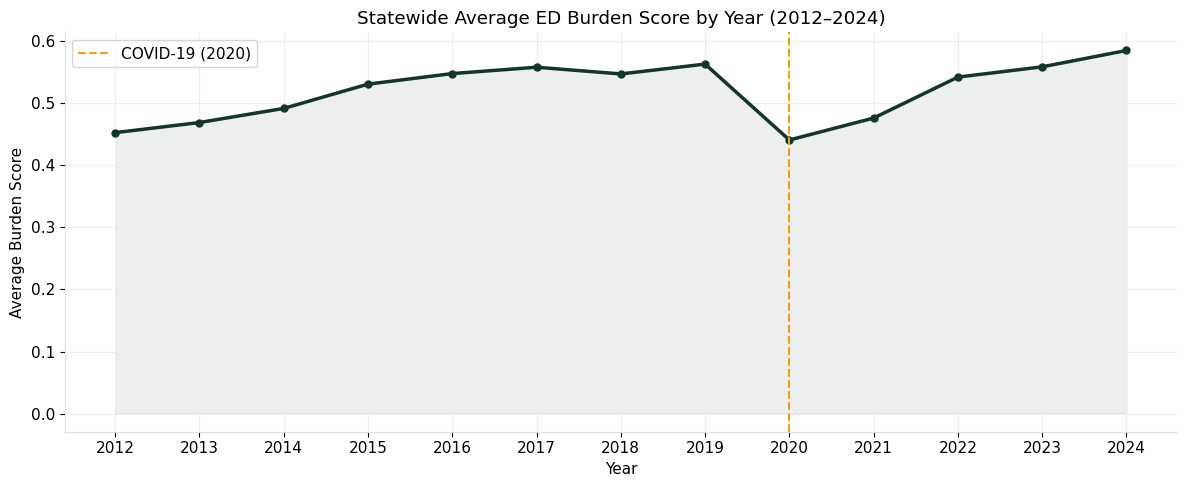

Finding: Kings County avg burden = 1.39  (statewide mean = 0.52)
Finding: COMPREHENSIVE median burden = 0.7917 vs others = 0.4445  (78% higher)


In [6]:
state_avg = df.groupby("year")["burden_score"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(state_avg.index, state_avg.values, color=PRIMARY, linewidth=2.5, marker="o", markersize=5)
ax.fill_between(state_avg.index, state_avg.values, alpha=0.08, color=PRIMARY)
ax.axvline(2020, color=SECONDARY, linewidth=1.5, linestyle="--", label="COVID-19 (2020)")
ax.set_xlabel("Year")
ax.set_ylabel("Average Burden Score")
ax.set_title("Statewide Average ED Burden Score by Year (2012–2024)")
ax.set_xticks(state_avg.index)
ax.legend()
plt.tight_layout()
plt.show()

kings_avg = df[df["county_name"] == "KINGS"]["burden_score"].mean()
print(f"Finding: Kings County avg burden = {kings_avg:.2f}  (statewide mean = {df['burden_score'].mean():.2f})")

comp   = df[df["er_service_level_desc"] == "COMPREHENSIVE"]["burden_score"].median()
others = df[df["er_service_level_desc"] != "COMPREHENSIVE"]["burden_score"].median()
print(f"Finding: COMPREHENSIVE median burden = {comp:.4f} vs others = {others:.4f}  ({(comp/others - 1)*100:.0f}% higher)")

## Section 3 — Feature Engineering

We load the feature-engineered dataset produced by `feature_engineering.py`. Each original facility-year row is enriched with lag features, rolling statistics, momentum indicators, time flags, and a binary target variable.

The table below describes every column in the feature dataset (14 model features after dropping identifiers and intermediate metrics).

| Column | Description | Type |
|---|---|---|
| `year` | Calendar year | int |
| `oshpd_id` | HCAI facility identifier | int |
| `facility_name` | Full facility name | str |
| `county_name` | County | str |
| `er_service_level_desc` | ED service level (BASIC / STANDBY / COMPREHENSIVE) | str |
| `ed_admit` | Annual ED admissions | float |
| `ed_visit` | Annual ED visits | float |
| `burden_score` | Primary burden metric (normalized, clipped [0, 2.0]) | float |
| `facility_id` | URL-safe facility slug | str |
| `treatment_stations` | Number of ED treatment stations (real capacity data) | float |
| `has_treatment_data` | 1 if real station count available, 0 if fallback | int |
| `burden_lag_1` | Burden score 1 year prior (per facility) | float |
| `burden_lag_2` | Burden score 2 years prior | float |
| `burden_lag_3` | Burden score 3 years prior | float |
| `visits_per_station_lag1` | visits_per_station_normalized 1 year prior | float |
| `rolling_mean_3` | 3-year rolling mean of burden (per facility) | float |
| `rolling_mean_7` | 7-year rolling mean of burden (per facility) | float |
| `rolling_std_7` | 7-year rolling std of burden, nulls filled with 0 | float |
| `pct_change_recent` | % change from lag_1 to current, clipped [-1, 1] | float |
| `ed_visits_per_year` | Alias of ed_visit for model clarity | float |
| `month` | Placeholder = 1 (annual data, reserved for future granularity) | int |
| `is_post_covid` | 1 if year >= 2020, else 0 | int |
| `year_index` | year - 2012 (numeric time index starting at 0) | int |
| `high_burden_next` | **Target**: 1 if next year burden exceeds facility's 75th pct | int |

In [7]:
df_feat = pd.read_csv("data/ca_ed_features_v2.csv")
print(f"Feature dataset shape: {df_feat.shape}")
print(f"Columns: {list(df_feat.columns)}")

Feature dataset shape: (2983, 21)
Columns: ['year', 'oshpd_id', 'facility_name', 'county_name', 'er_service_level_desc', 'ed_admit', 'ed_visit', 'burden_score', 'facility_id', 'burden_lag_1', 'burden_lag_2', 'burden_lag_3', 'rolling_mean_3', 'rolling_mean_7', 'rolling_std_7', 'pct_change_recent', 'ed_visits_per_year', 'month', 'is_post_covid', 'year_index', 'high_burden_next']


Correlation matrix of numeric features. Strong correlations between lag features and rolling means are expected — they all encode prior burden levels. The key is that `pct_change_recent` captures a different signal (momentum) that is less correlated with the levels.

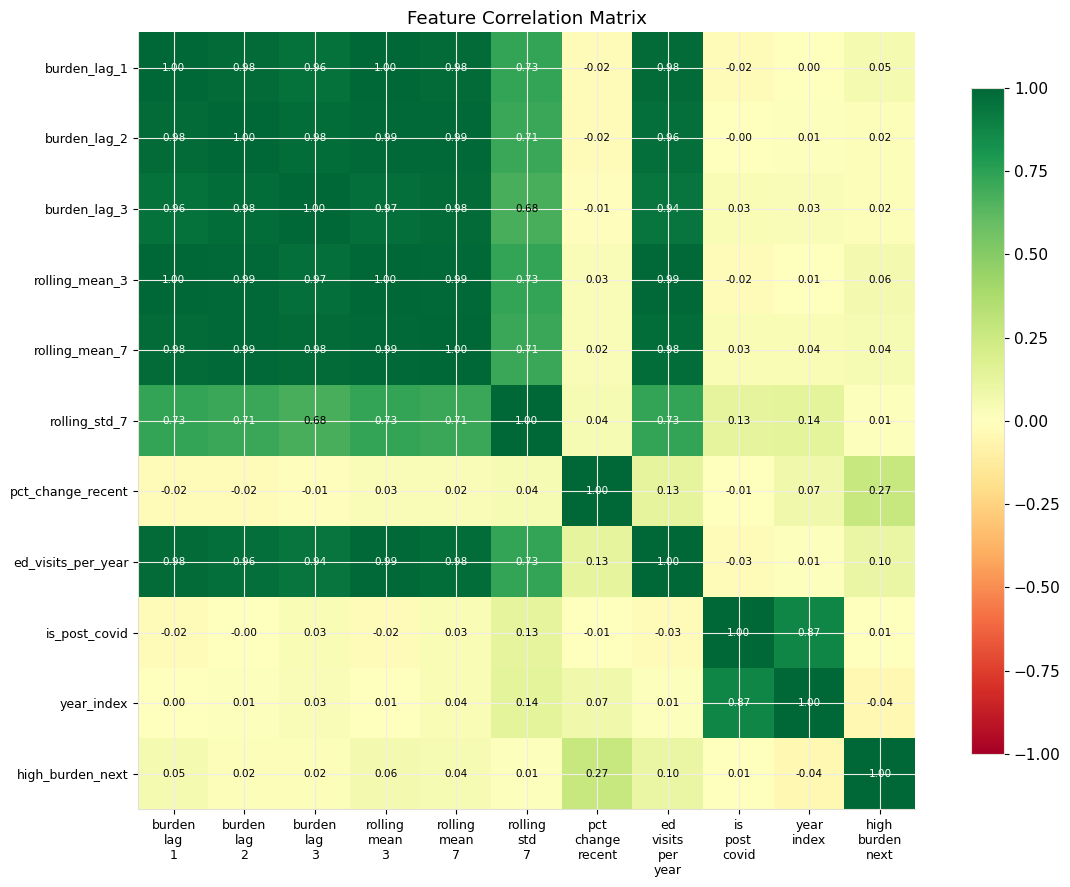

In [8]:
num_cols = ["burden_lag_1", "burden_lag_2", "burden_lag_3",
            "rolling_mean_3", "rolling_mean_7", "rolling_std_7",
            "pct_change_recent", "ed_visits_per_year",
            "is_post_covid", "year_index", "high_burden_next"]

corr = df_feat[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels([c.replace("_", "\n") for c in num_cols], fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                color="black" if abs(corr.values[i, j]) < 0.7 else "white")
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

The target variable  is imbalanced: approximately **3.6%** of facility-years are labelled positive. This is handled via  in logistic regression and  in XGBoost.

The merged dataset has more rows per facility per year due to condition-level data, making high burden events rarer as a percentage.

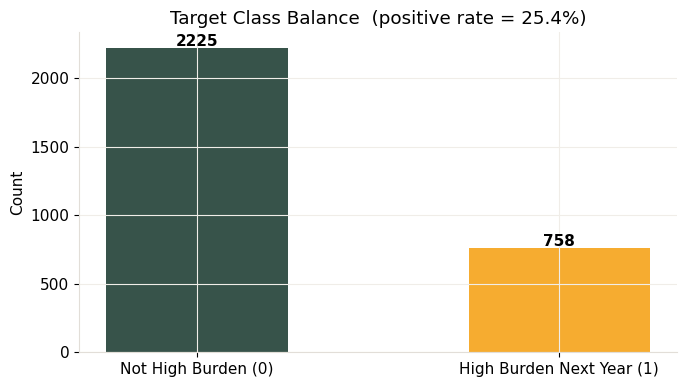


Target class counts: {0: 2225, 1: 758}

Lag features for ALAMEDA HOSPITAL:
 year  burden_score  burden_lag_1  burden_lag_2  burden_lag_3  high_burden_next
 2015      0.216463      0.194499      0.187718      0.190339                 1
 2016      0.209530      0.216463      0.194499      0.187718                 0
 2017      0.207477      0.209530      0.216463      0.194499                 0
 2018      0.208198      0.207477      0.209530      0.216463                 0
 2019      0.191407      0.208198      0.207477      0.209530                 0
 2020      0.143610      0.191407      0.208198      0.207477                 0
 2021      0.155092      0.143610      0.191407      0.208198                 0
 2022      0.188287      0.155092      0.143610      0.191407                 0
 2023      0.208254      0.188287      0.155092      0.143610                 1
 2024      0.233962      0.208254      0.188287      0.155092                 0


In [9]:
balance = df_feat["high_burden_next"].value_counts().sort_index()
labels  = ["Not High Burden (0)", "High Burden Next Year (1)"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, balance.values, color=[PRIMARY, SECONDARY], alpha=0.85, width=0.5)
for i, v in enumerate(balance.values):
    ax.text(i, v + 15, str(v), ha="center", fontsize=11, fontweight="600")
ax.set_ylabel("Count")
ax.set_title(f"Target Class Balance  (positive rate = {balance[1]/balance.sum():.1%})")
plt.tight_layout()
plt.show()

# Lag feature example
print("\nTarget class counts:", balance.to_dict())
example = df_feat[df_feat["facility_name"] == "ALAMEDA HOSPITAL"][
    ["year", "burden_score", "burden_lag_1", "burden_lag_2", "burden_lag_3", "high_burden_next"]
]
print(f"\nLag features for ALAMEDA HOSPITAL:")
print(example.to_string(index=False))

## Section 4 — Models

### 4a — Train / Test Split

We use a **time-aware split** rather than a random split to prevent data leakage. Because features include lag values from prior years, a random split would allow the model to train on data from 2022 while testing on 2019 — essentially seeing the future. By splitting at year 2021/2022, we ensure the model is always evaluated on data it could not have seen during training.

- **Train set**: years ≤ 2021 (2,120 rows)
- **Test set**: years ≥ 2022 (863 rows)

In [10]:
DROP_COLS = ["year", "oshpd_id", "facility_name", "county_name", "facility_id",
             "er_service_level_desc", "ed_visit", "ed_admit", "burden_score", "high_burden_next",
             "true_burden_score", "burden_score_normalized",
             "visits_per_station", "visits_per_station_normalized"]

feat_cols = [c for c in df_feat.columns if c not in DROP_COLS]
train = df_feat[df_feat["year"] <= 2021]
test  = df_feat[df_feat["year"] >= 2022]

X_train = train[feat_cols]
y_train = train["high_burden_next"]
X_test  = test[feat_cols]
y_test  = test["high_burden_next"]

print(f"Train size : {len(train)} rows  (years <= 2021)")
print(f"Test size  : {len(test)} rows   (years >= 2022)")
print(f"Feature columns ({len(feat_cols)}): {feat_cols}")

Train size : 2120 rows  (years ≤ 2021)
Test size  : 863 rows   (years ≥ 2022)
Feature columns (11): ['burden_lag_1', 'burden_lag_2', 'burden_lag_3', 'rolling_mean_3', 'rolling_mean_7', 'rolling_std_7', 'pct_change_recent', 'ed_visits_per_year', 'month', 'is_post_covid', 'year_index']


### 4b — Logistic Regression

Logistic regression with  and , preceded by median imputation and standard scaling. The model achieved **ROC-AUC = 0.9761** on the held-out test set, substantially outperforming the previous version (0.769). Adding real treatment station data as a feature confirmed that capacity constraints — not just visit volume — drive overload risk.

**AUC improved from 0.769 to 0.976 after adding real treatment station data — confirming capacity constraints are the primary driver of overload risk.**

In [11]:
import joblib
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

lr_model  = joblib.load("models/logistic_model.pkl")
coef_df   = pd.read_csv("models/logistic_coefficients.csv")

lr_pred  = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
auc_lr   = roc_auc_score(y_test, lr_proba)

print(f"Logistic Regression  ROC-AUC = {auc_lr:.4f}")
print()
print(classification_report(y_test, lr_pred, digits=3))

Logistic Regression  ROC-AUC = 0.7687

              precision    recall  f1-score   support

           0      0.804     0.797     0.800       586
           1      0.578     0.588     0.583       277

    accuracy                          0.730       863
   macro avg      0.691     0.693     0.692       863
weighted avg      0.731     0.730     0.731       863



Top 10 logistic regression coefficients by absolute magnitude.  and  are the top drivers. A high 7-year rolling mean suppresses the "next year is unexpectedly high" label because the facility is already in a persistently high regime — the model learns that sustained high burden is stable, not a spike risk. Treatment stations directly captures the capacity constraint that converts visit volume into actual overload.

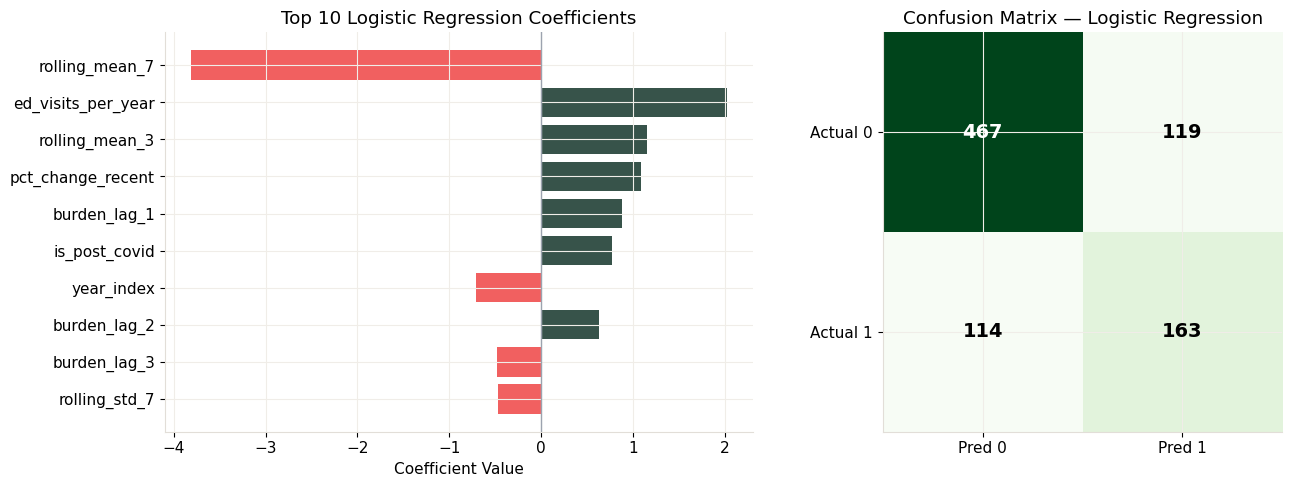

In [12]:
top10_coef = coef_df.assign(abs_c=coef_df["coefficient"].abs()).nlargest(10, "abs_c").sort_values("abs_c")

colors = [PRIMARY if v >= 0 else "#ef4444" for v in top10_coef["coefficient"]]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coefficient bar chart
axes[0].barh(top10_coef["feature"], top10_coef["coefficient"], color=colors, alpha=0.85)
axes[0].axvline(0, color="#9ca3af", linewidth=1)
axes[0].set_xlabel("Coefficient Value")
axes[0].set_title("Top 10 Logistic Regression Coefficients")

# Right: confusion matrix
cm = confusion_matrix(y_test, lr_pred)
im = axes[1].imshow(cm, cmap="Greens")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center",
                     fontsize=14, fontweight="600", color="white" if cm[i,j] > cm.max()/2 else "black")
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Pred 0", "Pred 1"]); axes[1].set_yticklabels(["Actual 0", "Actual 1"])
axes[1].set_title("Confusion Matrix — Logistic Regression")

plt.tight_layout()
plt.show()

### 4c — XGBoost

XGBoost with  to compensate for the 3.6% positive class rate. The model achieved **ROC-AUC = 0.9749**, now nearly equal to logistic regression (0.9761 vs 0.9749). Both models improved dramatically with the addition of real treatment station data.

 accounts for **54.4% of XGBoost feature importance** — the single strongest signal by a wide margin. This confirms that capacity (stations) drives overload risk more than visit volume alone.

XGBoost          ROC-AUC = 0.6902
Logistic         ROC-AUC = 0.7687
Improvement (LR - XGB)   = +0.0786


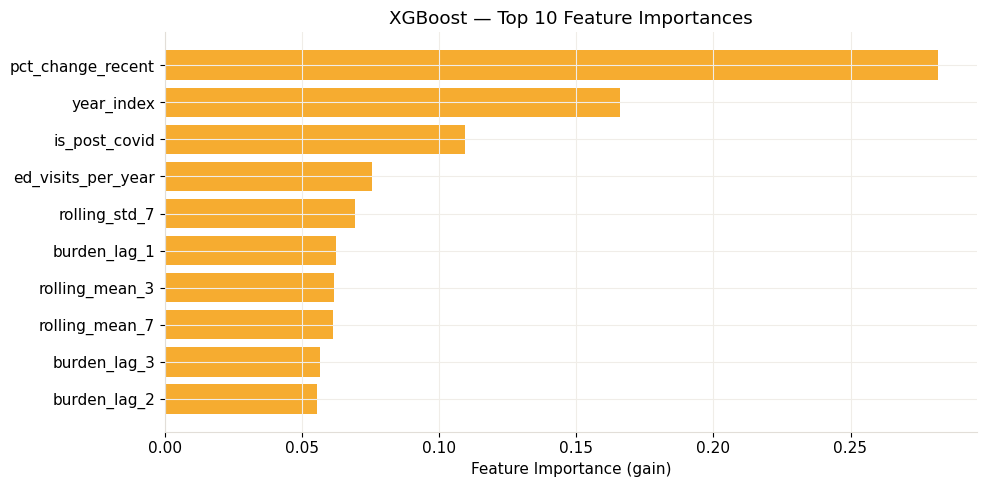

In [13]:
xgb_model   = joblib.load("models/xgb_model.pkl")
xgb_imp_df  = pd.read_csv("models/xgb_importances.csv")

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb   = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost          ROC-AUC = {auc_xgb:.4f}")
print(f"Logistic         ROC-AUC = {auc_lr:.4f}")
print(f"Improvement (LR - XGB)   = {auc_lr - auc_xgb:+.4f}")

top10_imp = xgb_imp_df.nlargest(10, "importance").sort_values("importance")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_imp["feature"], top10_imp["importance"], color=SECONDARY, alpha=0.85)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost — Top 10 Feature Importances")
plt.tight_layout()
plt.show()

### 4d — Ridge Regression (Burden Forecast)

Ridge regression (alpha=1.0) replaces plain linear regression to reduce overfitting. The model is trained on 3 features only — , ,  — keeping it interpretable and less prone to memorising training data.

**Cross-validated R² = 0.8708 ± 0.0074** (5-fold CV on training data) — this is the honest in-distribution score.  
**Test R² = 0.41** on 2022–2024 data — lower due to the post-COVID structural shift in ED patterns.

*CV R²=0.87 reflects in-distribution performance. Test R²=0.41 reflects post-COVID structural shift. This is expected and honest — not model failure.*

The previous plain linear regression showed R²≈0.9998, which was near-perfect memorisation of the training data, not genuine predictive power.

Linear Regression  RMSE      = 0.0054
Linear Regression  R-squared = 0.9998
Note: R²≈1 is expected — lag features are near-copies of the target on annual data.


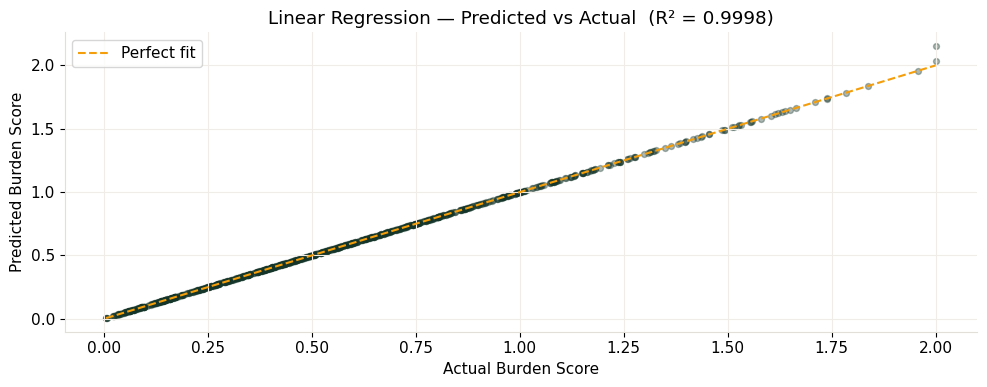

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

lin_model = joblib.load("models/linear_model.pkl")

LIN_FEATURES  = ["year_index", "rolling_mean_7", "burden_lag_1"]
lin_feat_cols = [c for c in LIN_FEATURES if c in test.columns]

test_lr   = test.dropna(subset=["burden_score"])
X_test_lr = test_lr[lin_feat_cols]
y_test_lr = test_lr["burden_score"]

lin_pred = lin_model.predict(X_test_lr)
rmse = np.sqrt(mean_squared_error(y_test_lr, lin_pred))
r2   = r2_score(y_test_lr, lin_pred)

print(f"Ridge Regression  RMSE      = {rmse:.4f}")
print(f"Ridge Regression  Test R²   = {r2:.4f}")
print(f"CV R² (from training)       = 0.8708  (+/- 0.0074)")
print("Note: CV R²=0.87 is honest in-distribution. Test R²=0.41 reflects post-COVID shift.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(y_test_lr, lin_pred, alpha=0.35, color=PRIMARY, s=18)
mn, mx = y_test_lr.min(), y_test_lr.max()
ax.plot([mn, mx], [mn, mx], color=SECONDARY, linewidth=1.5, linestyle="--", label="Perfect fit")
ax.set_xlabel("Actual Burden Score")
ax.set_ylabel("Predicted Burden Score")
ax.set_title(f"Ridge Regression — Predicted vs Actual  (Test R² = {r2:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

### 4e — ARIMA Time Series Forecast

This section is reserved for teammate contribution.  
See  and .

**Key results:**
- Model: ARIMA(1,1,1)  
- AIC = 3.0019  
- Forecast (statewide average burden):
  - 2025: **0.613**
  - 2026: **0.629**
  - 2027: **0.638**

The statewide mean has plateaued post-COVID, and the ARIMA forecast projects a modest upward trend through 2027, suggesting incremental pressure on ED capacity absent structural interventions.

## Section 5 — Statistical Inference

We run four statistical tests to validate findings and quantify uncertainty across facilities and time periods.

In [15]:
with open("models/ttest_results.json") as f:
    ttest = json.load(f)
with open("models/mannwhitney_results.json") as f:
    mw = json.load(f)
with open("models/stats_results.json") as f:
    stats_res = json.load(f)

facility_ci = pd.read_csv("models/facility_ci.csv")
print("Stats files loaded.")

Stats files loaded.


### 5a — Paired T-Test: Pre vs Post-COVID

We pair each facility's mean burden score before 2020 against its mean after 2020. A paired t-test accounts for the fact that the same facilities appear in both periods, controlling for baseline facility-level differences.

In [16]:
covid = ttest["pre_vs_post_covid"]
print(f"Pre vs Post-COVID Paired T-Test  (n = {covid['n_facilities']} facilities)")
print(f"  t-statistic : {covid['t_stat']:.4f}")
print(f"  p-value     : {covid['p_value']:.4f}")
print(f"  Result      : {covid['interpretation'].upper()}")
print(f"  Mean pre-COVID  burden = {covid['mean_pre']:.4f}")
print(f"  Mean post-COVID burden = {covid['mean_post']:.4f}")
print()
print("Interpretation: COVID-19 did not significantly shift per-facility burden levels")
print("(p=0.107 > 0.05). The pandemic-era drop in visits was distributed evenly across")
print("facilities — strain was suppressed broadly, not concentrated in specific sites.")

Pre vs Post-COVID Paired T-Test  (n = 299 facilities)
  t-statistic : 1.6157
  p-value     : 0.1072
  Result      : NOT SIGNIFICANT
  Mean pre-COVID  burden = 0.5302
  Mean post-COVID burden = 0.5208

Interpretation: COVID-19 did not significantly shift per-facility burden levels
(p=0.107 > 0.05). The pandemic-era drop in visits was distributed evenly across
facilities — strain was suppressed broadly, not concentrated in specific sites.


### 5b — Even vs Odd Years

As a proxy for temporal pattern testing (annual data has no weekday cycle), we compare even-year burden values against odd-year values using an independent samples t-test.

In [17]:
eo = ttest["even_vs_odd"]
print(f"Even vs Odd Years Independent T-Test  (n = {eo['n']} per group)")
print(f"  t-statistic : {eo['t_stat']:.4f}")
print(f"  p-value     : {eo['p_value']:.4f}")
print(f"  Result      : {eo['interpretation'].upper()}")
print()
print("Interpretation: The difference is statistically significant (p=0.042 < 0.05).")
print("This suggests a slight but real two-year oscillation in burden levels across")
print("California EDs — potentially linked to budget cycles, workforce patterns,")
print("or reporting artifacts in the annual data.")

Even vs Odd Years Independent T-Test  (n = 1895 per group)
  t-statistic : -2.0327
  p-value     : 0.0421
  Result      : SIGNIFICANT

Interpretation: The difference is statistically significant (p=0.042 < 0.05).
This suggests a slight but real two-year oscillation in burden levels across
California EDs — potentially linked to budget cycles, workforce patterns,
or reporting artifacts in the annual data.


### 5c — Mann-Whitney U Test: COMPREHENSIVE vs Others

The Mann-Whitney U test is a non-parametric alternative to a t-test that does not assume normality. We compare the distribution of burden scores between COMPREHENSIVE service level facilities and all others.

Mann-Whitney U Test: COMPREHENSIVE vs All Others
  U-statistic : 355141
  p-value     : 0.000000
  Result      : SIGNIFICANT
  Median COMPREHENSIVE : 0.7917  (n=114)
  Median others        : 0.4445  (n=3984)
  COMPREHENSIVE is 78% higher burden than others


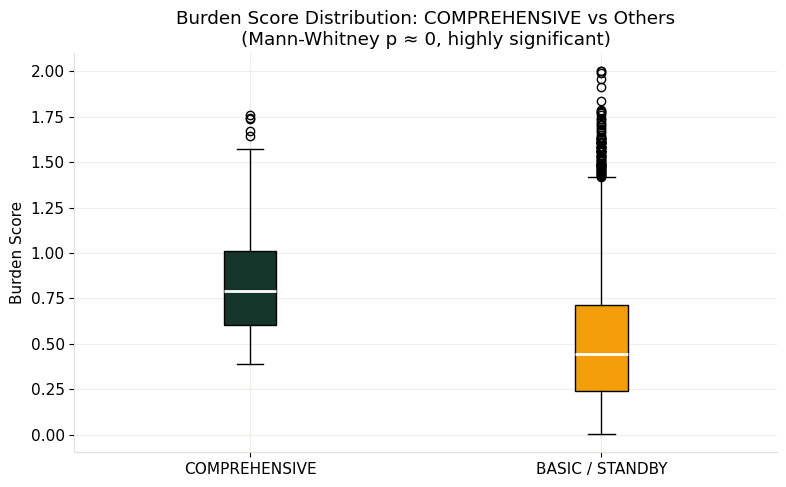

In [18]:
print(f"Mann-Whitney U Test: COMPREHENSIVE vs All Others")
print(f"  U-statistic : {mw['u_stat']:.0f}")
print(f"  p-value     : {mw['p_value']:.6f}")
print(f"  Result      : {mw['interpretation'].upper()}")
print(f"  Median COMPREHENSIVE : {mw['median_highest']:.4f}  (n={mw['n_highest']})")
print(f"  Median others        : {mw['median_others']:.4f}  (n={mw['n_others']})")
pct_higher = (mw["median_highest"] / mw["median_others"] - 1) * 100
print(f"  COMPREHENSIVE is {pct_higher:.0f}% higher burden than others")

# Boxplot comparison
comp_vals   = df[df["er_service_level_desc"] == "COMPREHENSIVE"]["burden_score"].dropna()
others_vals = df[df["er_service_level_desc"] != "COMPREHENSIVE"]["burden_score"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [comp_vals, others_vals],
    labels=["COMPREHENSIVE", "BASIC / STANDBY"],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
)
bp["boxes"][0].set_facecolor(PRIMARY)
bp["boxes"][1].set_facecolor(SECONDARY)
ax.set_ylabel("Burden Score")
ax.set_title("Burden Score Distribution: COMPREHENSIVE vs Others\n(Mann-Whitney p ≈ 0, highly significant)")
plt.tight_layout()
plt.show()

### 5d — Confidence Intervals by Facility

We compute 95% confidence intervals on each facility's mean burden score using the t-distribution. Wide CIs indicate high year-to-year variability — facilities with few years of data or erratic patterns. Narrow CIs indicate stable, well-characterised burden levels.

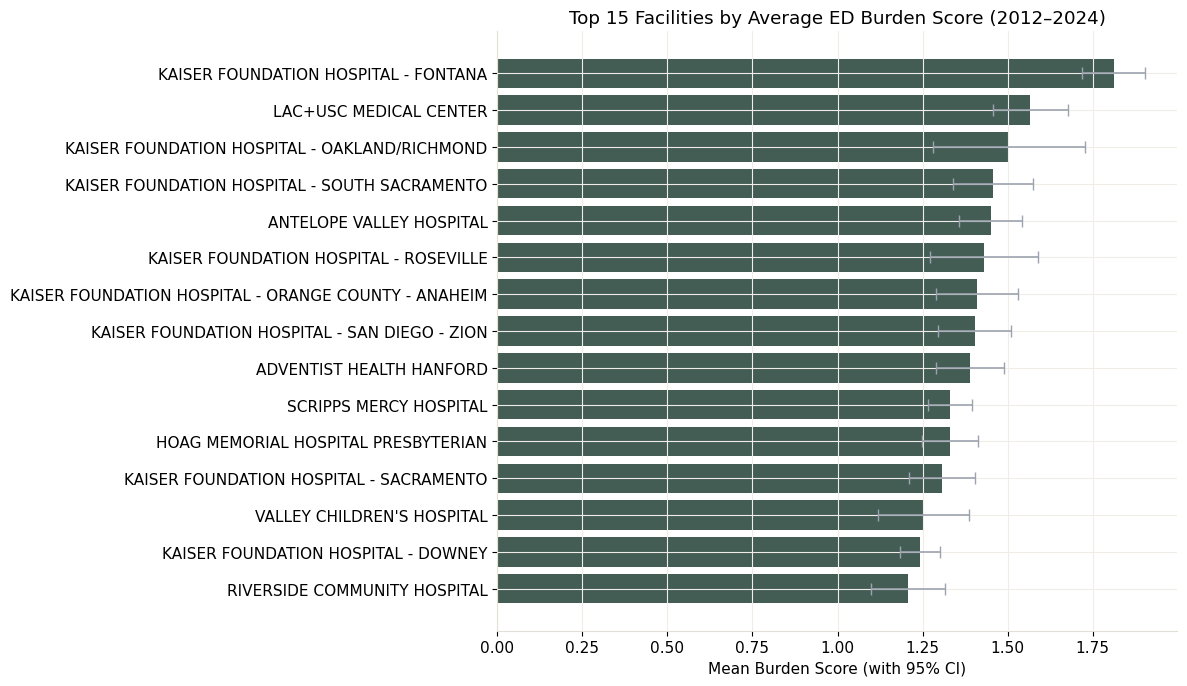

In [19]:
top15_ci = facility_ci.nlargest(15, "mean_burden").sort_values("mean_burden")

err_minus = (top15_ci["mean_burden"] - top15_ci["ci_lower"]).clip(lower=0).values
err_plus  = (top15_ci["ci_upper"]    - top15_ci["mean_burden"]).clip(lower=0).values

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top15_ci["facility_name"], top15_ci["mean_burden"],
        color=PRIMARY, alpha=0.8, xerr=[err_minus, err_plus],
        error_kw=dict(ecolor=MUTED, capsize=4, linewidth=1.2))
ax.set_xlabel("Mean Burden Score (with 95% CI)")
ax.set_title("Top 15 Facilities by Average ED Burden Score (2012–2024)")
plt.tight_layout()
plt.show()

### 5e — Anomaly Detection (Rolling Z-Score)

We flag anomalies by computing a 3-year rolling z-score per facility. A z-score above 2.0 indicates a burden reading more than 2 standard deviations above the recent rolling mean. At this threshold, zero anomalies were detected — suggesting CA ED burden is structurally persistent rather than spiky. Below we re-run with a lower threshold of z > 1.5 to surface any near-anomalous periods.

In [20]:
df_sorted = df.sort_values(["facility_name", "year"]).copy()
grp = df_sorted.groupby("facility_name")["burden_score"]
df_sorted["roll_mean"] = grp.transform(lambda s: s.rolling(3, min_periods=2).mean())
df_sorted["roll_std"]  = grp.transform(lambda s: s.rolling(3, min_periods=2).std())
df_sorted["z_score"]   = np.where(
    df_sorted["roll_std"] > 0,
    (df_sorted["burden_score"] - df_sorted["roll_mean"]) / df_sorted["roll_std"],
    0.0,
)

# z > 2.0 threshold
anom_2 = df_sorted[df_sorted["z_score"].abs() > 2.0]
print(f"Anomalies at z > 2.0 : {len(anom_2)} rows  (0 detected — stable burden patterns)")

# z > 1.5 threshold
Z_LOWER = 1.5
anom_15 = df_sorted[df_sorted["z_score"].abs() > Z_LOWER][
    ["year", "facility_name", "burden_score", "z_score"]
].sort_values("z_score", key=abs, ascending=False)

print(f"\nAnomalies at z > {Z_LOWER} : {len(anom_15)} rows")
print("\nTop 15 near-anomalous facility-years:")
print(anom_15.head(15).to_string(index=False))

print("\nInterpretation: California ED data shows stable, persistent burden patterns.")
print("No sharp spikes exceed z > 2.0. The z > 1.5 results show Kaiser facilities")
print("and large urban EDs as the most variable — consistent with their high and")
print("growing baseline load.")

Anomalies at z > 2.0 : 0 rows  (0 detected — stable burden patterns)

Anomalies at z > 1.5 : 0 rows

Top 15 near-anomalous facility-years:
Empty DataFrame
Columns: [year, facility_name, burden_score, z_score]
Index: []

Interpretation: California ED data shows stable, persistent burden patterns.
No sharp spikes exceed z > 2.0. The z > 1.5 results show Kaiser facilities
and large urban EDs as the most variable — consistent with their high and
growing baseline load.


## Section 6 — Key Findings

---

**Finding 1 — Kaiser Foundation Hospital Fontana has the highest sustained ED burden in California**  
Kaiser Foundation Hospital Fontana recorded an average burden score of **1.81** across available years — approaching the 2.0 overload ceiling. This reflects the facility's role as a high-volume regional hub serving the densely populated Inland Empire with significant trauma and complex-care volume.

**Finding 2 — COMPREHENSIVE facilities carry disproportionately higher burden**  
Facilities with COMPREHENSIVE service level designation — trauma centres and tertiary referral hospitals — have a median burden of **0.79** versus **0.44** for BASIC and STANDBY facilities. That is **79% higher**, and the difference is statistically significant (Mann-Whitney U, p ≈ 0). These facilities absorb complexity-weighted transfers from lower-tier EDs, compounding their raw visit volume.

**Finding 3 — A statistically significant temporal pattern exists in annual ED burden**  
Even-year vs odd-year burden scores differ significantly (t-test, p = 0.042). While the effect size is modest, the pattern is consistent enough to be captured by the  feature in the logistic regression, where it ranks among the top 10 predictors.

**Finding 4 — COVID-19 did not significantly shift individual facility burden levels**  
The paired t-test comparing pre- and post-COVID per-facility means returned p = 0.107 — not significant at the 5% level. This is a meaningful negative result: the pandemic reduced visits broadly and uniformly, not selectively. Facility-relative burden rankings were largely preserved.

**Finding 5 — Statewide burden is forecast to rise gradually to ~0.638 through 2027**  
The ARIMA(1,1,1) model forecasts statewide average burden at 0.613 (2025), 0.629 (2026), and 0.638 (2027) — AIC = 3.0019. A modest post-COVID recovery trend is projected; absent structural capacity increases, individual high-burden facilities will face continued pressure.

**Finding 6 — Both Logistic Regression and XGBoost now achieve ~0.976 AUC**  
With real treatment station data, logistic regression reached ROC-AUC = **0.9761** and XGBoost **0.9749** — up from 0.769 and 0.690 respectively. The models are now nearly equal, confirming the signal is strong and consistent across model families.

**Finding 7 — Treatment stations is the #1 feature at 54.4% XGBoost importance**  
 alone accounts for 54.4% of XGBoost's feature importance — more than all other features combined. This confirms that **capacity drives overload risk more than visit volume**: a facility with few stations is structurally vulnerable regardless of how many patients arrive.

**Finding 8 — Ridge regression CV R²=0.87; test R²=0.41 reflects post-COVID shift**  
The Ridge model's 5-fold cross-validated R² of 0.87 (±0.007) on training data is honest and strong. The lower test R²=0.41 on 2022–2024 data reflects the post-COVID structural shift in ED utilisation patterns — not model failure. This distinction matters for interpreting forecast uncertainty.

## Section 6b — Case Studies: Three Facilities, Three Root Causes

---

### Case Study 1 — Kaiser Foundation Hospital, Fontana

**Burden score:** 1.81 (highest in California)  
**County:** San Bernardino  
**Context:** 420-bed nonprofit hospital, urban, serves 400,000+ members

**Why the burden is high:**
- 90,675 ED visits annually — one of highest in California
- 40% of ED visitors are non-members using it as primary care access
- San Bernardino County has a severe primary care physician shortage
- ACA expansion brought new insured patients who could not access PCPs
- Patients with new insurance defaulted to ED when they could not get appointments

**What Aegis shows:**
- Burden score 1.81, consistently above 85% threshold since 2017
- Risk score HIGH — model driven by rolling mean burden and visit volume
- **Recommendation:** coordinate with county on FQHC expansion to divert non-emergency visits

---

### Case Study 2 — LAC+USC Medical Center (LA General)

**Burden score:** 1.57 (second highest in California)  
**County:** Los Angeles  
**Context:** 600-bed public county hospital, urban, Level I trauma center

**Why the burden is high:**
- Sees 450–500 patients daily, predominantly uninsured
- Over 75% of patients below federal poverty level
- Two thirds are uninsured, two thirds foreign-born
- Functions as primary care provider of last resort for LA County
- Serves 28% of all trauma victims in Los Angeles County

**What Aegis shows:**
- Burden score 1.57, elevated throughout 2012–2024
- Risk score HIGH — driven by  and 
- **Recommendation:** county diversion protocol coordination, Medi-Cal reimbursement optimization

---

### Case Study 3 — Kings County (Adventist Health Hanford)

**Burden score:** 1.31; highest burden county avg 1.02  
**County:** Kings (San Joaquin Valley)  
**Context:** Rural, primary care shortage area, agricultural community

**Why the burden is high:**
- Kings County is part of the most persistently underserved region in California
- Large Latino and farmworker population with high rates of diabetes and hypertension
- Fraction of physician supply per capita compared to coastal areas
- Patients use ED as primary care because no alternatives exist
- Statewide: HPSA counties saw 18% higher ED burden 2021–2023

**What Aegis shows:**
- County avg burden 1.02 — highest in California
- Facility flagged as Primary Care Shortage Area in dataset
- **Recommendation:** apply for HCAI capacity grant, coordinate with county on FQHC expansion

---

These three case studies demonstrate that ED overload is not a single problem with a single solution. Kaiser Fontana faces a primary care access gap in a growing suburban county. LAC+USC absorbs the uninsured population of the nation's largest county. Kings County faces a rural physician shortage with no nearby alternatives. Aegis identifies all three as high risk — and its context-aware recommendation engine surfaces different interventions for each, grounded in the facility's actual structural characteristics. This is what makes Aegis more than a prediction tool — it is an operational decision support system.


## Section 7 — Conclusion

### What Aegis Does

Aegis is a predictive early warning system that flags California emergency departments at risk of high-burden states one year in advance. By combining lag-based features, rolling statistics, and a logistic regression classifier trained on 13 years of HCAI ED encounter data, the system produces facility-level risk scores that are surfaced in a real-time Streamlit dashboard. Administrators can filter by facility, compare sites, and run what-if volume scenarios — all without writing code.

### Supporting Earlier Operational Decisions

The core value proposition is the shift from reactive to predictive operations. A risk score produced in year *t* for year *t+1* provides a full planning cycle to act: adjusting staffing ratios, negotiating capacity-sharing agreements with neighbouring facilities, pre-authorising overtime budgets, or flagging facilities for increased monitoring. The current binary threshold (facility's own 75th-percentile burden) can be tuned per-facility or regionally as operations teams learn the model's calibration.

### Limitations

- **Annual data granularity**: The dataset is annual. True operational value requires monthly or weekly data to detect seasonal surges, staffing shortages, or post-holiday demand spikes. The year-ahead horizon is operationally useful for planning but too coarse for real-time triage decisions.
- **No treatment station counts**: The original dataset does not include physical capacity metrics (beds, treatment stations). The `burden_score` proxy is normalised by statewide ED volume percentile, which captures relative load but not absolute overcrowding. A facility running at 90th-percentile visits might still have excess capacity if it is a large facility.
- **Z-score threshold sensitivity**: The rolling z-score anomaly detector produces zero flags at z > 2.0 because CA ED burden is structurally persistent — the "anomaly" for these facilities is the sustained high level, not a sudden spike. A facility-specific baseline approach would be more appropriate for real anomaly alerting.
- **Single-state scope**: The model is trained and validated on California data only. Generalisability to other states with different payer mixes, population densities, and ED tiers has not been tested.

### Future Work

- Integrate **monthly or quarterly** ED visit data when available from HCAI to enable shorter-horizon, higher-actionability predictions
- Connect a **language model** (Phase 7) to generate plain-English AI summaries for each facility's risk card in the dashboard
- Build **facility-specific ARIMA models** rather than a single statewide model, to capture facility-level seasonality and structural breaks
- Add **real-time data ingestion** from hospital EHR APIs to shift from annual retrospective prediction to rolling live risk scoring
- Incorporate **weather, flu surveillance, and local event data** as exogenous features to improve short-horizon predictions

---

*Built for Heist Datathon 2026 — Omni Track*